In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# базисной функции,
# используемой для конструирования
# точного решения ДУ (8.151) с S = 0
def FNGAUSS(t, x):
    z = np.exp(-20 * (x - 0.5) ** 2 / (1 + 80 * t)) / np.sqrt(1 + 80 * t)

    return z


In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения точного решения (8.152) c S = 0
def FNEXACT(t, x):
    z = FNGAUSS(t, x) - FNGAUSS(t, x - 1) - FNGAUSS(t, x + 1)

    return z


In [4]:
# Ячейка № 4

# задание функции, возвращающей массивы,
# содержащие значения узлов временной сетки (t),
# узлов координатной сетки (x),
# численного решения СДУ (8.148) (S),
# значений аналитического решения СДУ (8.148) (S1),
# разностей между точным и
# численным решениями ДУ (8.148)


def Solv_LTG(N, NT, Tfin):
    # входные переменные:
    # N - число узлов сетки по оси OX
    # NT - число узлов ВС,
    # Tfin - длительность временного интервала

    # вычисление значений
    # координат узлов сетки по оси OX
    x = np.linspace(0, 1.0, N)

    # вычисление шага координатной сетки
    dx = x[1] - x[0]

    # вычислений значений узлов временной сетки
    t = np.linspace(0, Tfin, NT + 1)

    # вычисление шага временной сетки
    dt = t[1] - t[0]

    # вычисление отношения шага временной сетки к
    # квадрату шага координатной сетки
    dTH = dt / dx**2

    # инициализация массива,
    # используемого для хранения значений
    # конечно-разностной производной
    # функции phi по времени
    Phi = np.zeros(N)

    # инициализация массива, используемого для
    # хранения численных решений ДУ (8.148)
    S = np.zeros([NT, N])

    # инициализация массива,
    # используемого для
    # хранения точных решений ДУ (8.148)
    S1 = np.zeros([NT, N])

    # инициализация массива, используемого для
    # хранения модуля разностей между
    # точными и численными решений ДУ (8.148)
    S3 = np.zeros([NT, N])

    # задание начальных условий
    for i in range(N - 2):
        Phi[i + 1] = FNEXACT(0, x[i + 1])

    # Задание начальных условий
    for i in range(N - 1):
        S[0, i + 1] = Phi[i + 1]
        S1[0, i + 1] = Phi[i + 1]

    # вычисление значений точного решения ДУ(8.148)
    # в узлах используемой координатно-временной сетки
    for i in range(NT - 1):
        for m in range(N - 2):
            S1[i + 1, m + 1] = FNEXACT(t[i + 1], x[m + 1])

    # задание значение коэффициента A[0, j]
    AP = -dTH
    # задание значение коэффициента A[+-, j]
    AZ = 1 + 2 * dTH

    # инициализация массивов, используемых
    # в методе прогонки
    Alpha = np.zeros(N)
    Gamma = np.zeros(N)
    Beta = np.zeros(N)

    # задание начального значения
    # коэффициента gamma
    Gamma[N - 1] = -1 / AZ
    Alpha[N - 1] = 0
    Beta[N - 1] = 0

    # вычисление коэффициентов Alpha, Gamma
    # методом обратной прогонки
    i = N - 1
    while i >= 1:
        Alpha[i - 1] = Gamma[i] * AP
        Gamma[i - 1] = -1 / (AZ + AP * Alpha[i])
        i = i - 1
    # вычисление численного
    # решения СДУ (8.148)
    for m in range(NT):  # цикл по времени
        # вычисление коэффициентов Beta
        # методом обратной прогонки
        Beta[N - 1] = 0
        i = N - 1
        while i >= 1:
            Beta[i - 1] = Gamma[i] * (AP * Beta[i] - Phi[i])
            i = i - 1

        # вычисление численных
        # решений СДУ (8.147)

        for i in range(N - 2):
            # вычисление значений phi
            # i+1-ом шаге по времени
            Phi[i + 1] = Alpha[i] * Phi[i] + Beta[i]

            # сохранение вычисленного значения
            # i+1-ом шаге по времени
            # численного решения уравнения (8.148)
            # в массив S
            S[m, i + 1] = Phi[i + 1]

    # вычисление в узлах используемой
    # координатно-временной сетки
    # разностей между точным и
    # численным решениями ДУ (8.148)
    S3 = S1 - S

    return t, x, S, S1, S3


In [ ]:
# Ячейка № 5

# задание числа узлов координатной сетки
N = 25

# задание числа узлов временной сетки
NT = 180

# задание правой границы временного интервала
Tfin = 0.18

# вызов функции, возвращающей массивы,
# содержащие значения узлов временной сетки (t),
# узлов координатной сетки (x),
# численного решения СДУ (8.148) (S),
# значений аналитического решения СДУ (8.148) (S1),
# разностей между точным и
# численным решениями ДУ (8.148)
t, x, S, S1, S3 = Solv_LTG(N, NT, Tfin)


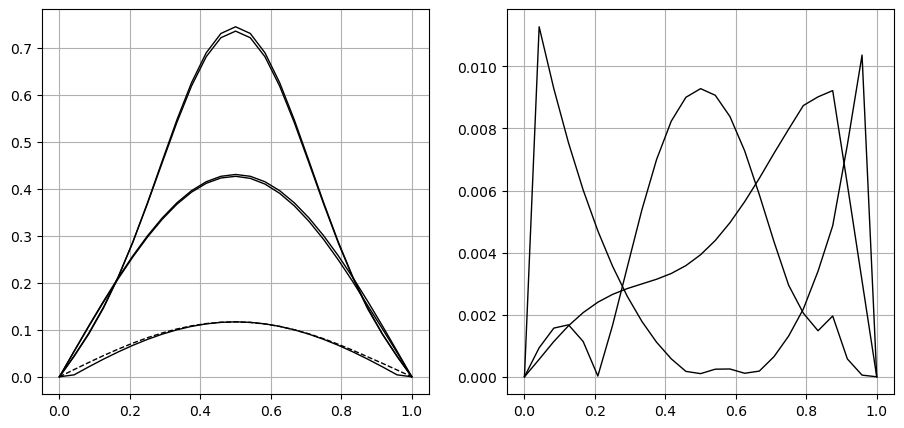

In [6]:
# Ячейка № 6

# визуализация модулей точного и
# численного решений СДУ (8.148)
# и зависимости модуля разности
# от времени между ними

# визуализация модулей точного и
# численного решений
fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x[:], abs(S1[10, :]), "-k", lw=1)
ax.plot(x[:], abs(S[10, :]), "-k", lw=1)
ax.plot(x[:], abs(S1[50, :]), "-k", lw=1)
ax.plot(x[:], abs(S[50, :]), "-k", lw=1)
ax.plot(x[:], abs(S1[179, :]), "-k", lw=1)
ax.plot(x[:], abs(S[179, :]), "--k", lw=1)
ax.tick_params(labelsize=10)
ax.grid(True)

# визуализация зависимости
# модулей разностей между
# точным и численным решениями
ax = fig.add_subplot(1, 2, 2)
ax.plot(x[:], abs(S3[10, :]), "-k", lw=1)
ax.plot(x[:], abs(S3[50, :]), "-k", lw=1)
ax.plot(x[:], abs(S3[179, :]), "-k", lw=1)
ax.tick_params(labelsize=10)
ax.grid(True)

plt.show()